In [1]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from tqdm import tqdm

In [2]:
from selenium.webdriver.common.by import By

In [3]:
options = webdriver.EdgeOptions()

In [4]:
options.add_argument('--no-sandbox')
options.add_experimental_option('excludeSwitches', ['enable-automation'])
options.add_experimental_option('useAutomationExtension', False)

In [5]:
service = Service(r'./msedgedriver.exe') 

In [6]:
driver = webdriver.Edge(options=options,service=service)

In [7]:
driver.maximize_window()
driver.execute_cdp_cmd("Page.addScriptToEvaluateOnNewDocument", {
    "source": """
    Object.defineProperty(navigator, 'webdriver', {
        get: () => undefined
    })
    """
})

{'identifier': '2'}

In [8]:
driver.get('https://iccv.thecvf.com/Conferences/2025/AcceptedPapers')

In [10]:
btn = driver.find_element(By.XPATH,"/html/body/main/div[2]/div/div/table/tbody/tr[3]/td[1]/strong")

In [11]:
btn.text

'Joint Learning of Pose Regression and Denoising Diffusion with Score Scaling Sampling for Category-level 6D Pose Estimation'

In [13]:
title_list = []
withcode = 0
xpath_tmp = "/html/body/main/div[2]/div/div/table/tbody/tr[{}]/td[1]/"
for i in tqdm(range(3,2704)):
    xpath_id = xpath_tmp.format(i)
    try:
        btn = driver.find_element(By.XPATH,xpath_id+"a")
        withcode += 1
    except:
        btn = driver.find_element(By.XPATH,xpath_id+"strong")
    finally:
        title_list.append(btn.text)

100%|██████████████████████████████████████████████████████████████████████████████| 2701/2701 [01:18<00:00, 34.53it/s]


In [14]:
withcode/len(title_list)* 100 

13.143280266567938

In [15]:
title_list

['Joint Learning of Pose Regression and Denoising Diffusion with Score Scaling Sampling for Category-level 6D Pose Estimation',
 'Hybrid-TTA: Continual Test-time Adaptation via Dynamic Domain Shift Detection',
 'On the Recovery of Cameras from Fundamental Matrices',
 'Vulnerability-Aware Spatio-Temporal Learning for Generalizable Deepfake Video Detection',
 'SegmentDreamer: Towards High-fidelity Text-to-3D Synthesis with Segmented Consistency Trajectory Distillation',
 'Learnable Feature Patches and Vectors for Boosting Low-light Image Enhancement without External Knowledge',
 'REPARO: Compositional 3D Assets Generation with Differentiable 3D Layout Alignment',
 'Fine-grained Spatiotemporal Grounding on Egocentric Videos',
 'Toward Fair and Accurate Cross-Domain Medical Image Segmentation: A VLM-Driven Active Domain Adaptation Paradigm',
 'Boosting Adversarial Transferability via Residual Perturbation Attack',
 'HypDAE: Hyperbolic Diffusion Autoencoders for Hierarchical Few-shot Image 

In [16]:
driver.close()

In [17]:
import json

In [18]:
with open("ICCV_2025_title.json", 'w') as  f:
    json.dump(title_list, f)

In [19]:
from wordcloud import (WordCloud, get_single_color_func, STOPWORDS, ImageColorGenerator)
import matplotlib.pyplot as plt

In [20]:
txt_stop = """a an . , : ? the is in to of via be from by with and or for - on"""

In [21]:
text_all = " ".join(title_list)

In [22]:
stop_words_list = txt_stop.split(" ")
stopwords = set(STOPWORDS)
for w in stop_words_list:
    stopwords.add(w)

In [23]:
wordcloud = WordCloud(
    background_color="white",
    width=1000, 
    height=860, 
    margin=2,
    max_font_size=196,
    max_words=256,
    random_state=96,
    stopwords=stopwords,
).generate(text_all.lower())

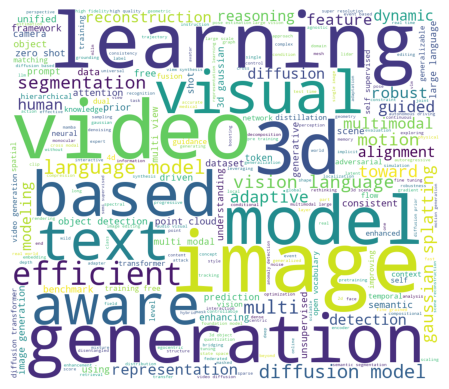

In [24]:
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [25]:
wordcloud.to_file('wordcloud_ICCV2025_title.pdf')

In [26]:
from collections import Counter

In [27]:
wordcount = Counter([i.lower() for i in text_all.split(" ") if i.lower() not in stop_words_list])

In [28]:
wordcount

Counter({'learning': 315,
         'image': 314,
         '3d': 306,
         'models': 302,
         'diffusion': 289,
         'generation': 280,
         'video': 248,
         'model': 164,
         'detection': 159,
         'visual': 153,
         'segmentation': 146,
         'gaussian': 136,
         'object': 134,
         'efficient': 118,
         'multimodal': 117,
         'reconstruction': 114,
         'motion': 110,
         'large': 108,
         'scene': 103,
         'language': 92,
         'towards': 88,
         'splatting': 88,
         'semantic': 86,
         'human': 81,
         'vision-language': 80,
         'framework': 75,
         'robust': 72,
         'vision': 71,
         'unified': 71,
         'estimation': 69,
         'point': 69,
         'understanding': 68,
         'representation': 68,
         'modeling': 65,
         'adaptive': 65,
         'dynamic': 64,
         'alignment': 64,
         'prediction': 64,
         'dataset': 64,
       